In [1]:
# Extra dependencies for the Hindi adaptation. This cell is to be run once per environment, and the Hindi fastText model will be cached on disk after the first run.

%pip install fasttext-wheel
%pip install gensim


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import random
import math
import nltk
import nltk.corpus

nltk.download('indian')

os.makedirs('./results', exist_ok=True)

with open('./brown_100.txt', 'r') as file_:
    corpus = file_.read()

indian = nltk.corpus.indian

def write_freqs(list_: list, filename: str) -> None:
    with open(f'./results/{filename}.txt', 'w') as file_:
        file_.write('\n'.join([' '.join(x[0]) + ' | ' + str(x[1]) for x in list_]))

# Build a Hindi corpus from the Indian Language Corpus.
# We use Hindi for the Indian-side embedding analysis because it was readable and workable for our group.
# To make the Hindi side comparable in scale to Brown100, we take a random subsample of 100 Hindi sentences from the ILC
# (full Hindi file ~540 sentences). Random rather than first-N avoids concentrating on whichever articles appear first
# in the file. A fixed seed makes the subsample reproducible.
HINDI_N_SENTS = 100
random.seed(42)
all_hindi_sents = list(indian.sents('hindi.pos'))
hindi_sents = random.sample(all_hindi_sents, HINDI_N_SENTS)

hindi_text = ""
for sent in hindi_sents:
    hindi_text += "<s> " + " ".join(sent) + " </s> "

# Helper for identifying Devanagari tokens.
# Used downstream to filter Hindi tokens (exclude Latin punctuation, sentence markers, etc.)
devanagari_pattern = re.compile(r'[\u0900-\u097F]')

def is_devanagari_token(token: str) -> bool:
    return bool(devanagari_pattern.search(token)) and token not in {'<s>', '</s>'}

[nltk_data] Downloading package indian to
[nltk_data]     /Users/shreyabhatt/nltk_data...
[nltk_data]   Package indian is already up-to-date!


In [3]:
corpus

"<s> The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place . </s> \n<s> The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted . </s> \n<s> The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigate reports of possible `` irregularities '' in the hard-fought primary which was won by Mayor-nominate Ivan Allen Jr. . </s> \n<s> `` Only a relative handful of such reports was received '' , the jury said , `` considering the widespread interest in the election , the number of voters and the size of this city '' . </s> \n<s> The jury said it did find that many of Georgia's registration and election laws `` are outmoded or inadequate and often ambiguous '' . </s> \n

## N-Gram Language Modeling
In the second assignment, you will implement an **n-gram language model** that processes input text to generate, analyze, and calculate the probabilities of sequences of `n` words (n-grams). This model will tokenize text, create n-grams, and compute their frequencies and probabilities, returning the most frequent n-grams in the text.

1. **Tokenization**: Convert the input text into a list of words (tokens).
2. **N-gram Generation**: Create sequences of `n` tokens from the text, treating each sentence independently with the inclusion of start (`<s>`) and end (`</s>`) markers.
3. **Frequency Counting**: Count how many times each n-gram appears in the text.
4. **Probability Calculation**: Compute the probabilities of each n-gram based on its frequency and add alpha smoothing to improve generalization of items.
5. **Most Frequent N-grams**: Return the most frequent n-grams along with their probabilities, helping to identify common patterns in the text.

In [4]:
from collections import Counter, defaultdict

In [5]:
class NGramModel:
    def __init__(self, text, n, alpha=0.0):
        """
        Initialize the NGramModel with text and the value of n.
        """
        self.text = text
        self.n = n
        self.alpha = alpha  # Alpha value for additive smoothing
        self.ngrams = []
        self.probabilities = {}
        self.vocab = set()

    def tokenize(self) -> list:
        """
        Tokenize the text into words. 
        Fill in the code to split the text into a list of words.
        """
        
        tokens = self.text.lower().split()
        
        self.vocab.update(tokens)
        # print(tokens)
        # raise NotImplementedError
        return tokens

    def generate_ngrams(self, tokens: list) -> list:
        """
        Generate n-grams from the list of tokens.
        Fill in the code to create n-grams.
        Make sure to treat each sentence independently, include the <s> and </s> tokens.
        """
        sentences = []
        current = []
        for token in tokens:
            current.append(token)
            if token == '</s>': 
                sentences.append(current)
                current = []
        if current:  
            sentences.append(current)
        ngrams = []
        for sentence in sentences:
            sentence_ngrams = [sentence[i:i+self.n] for i in range(len(sentence) - self.n + 1)]
            ngrams.extend(sentence_ngrams)
        self.ngrams = ngrams
        # print(self.ngrams)

        return self.ngrams
    
    def count_frequencies(self) -> None:

        """
        Count the frequencies of each n-gram.
        Fill in the code to count n-gram occurrences.
        """
        self.ngram_freqs = Counter(tuple(ngram) for ngram in self.ngrams)
        self.context_freqs = Counter(tuple(ngram[:-1]) for ngram in self.ngrams)
        # print(self.ngram_freqs)
        # raise NotImplementedError

    def calculate_probabilities(self) -> None:
        """
        Calculate probabilities of each n-gram based on its frequency. Add alpha smoothing separately.
        """
        V = len(self.vocab)
        for ngram, freq in self.ngram_freqs.items():
            context = ngram[:-1]
            context_count = self.context_freqs[context]
            self.probabilities[ngram] = (freq + self.alpha) / (context_count + self.alpha * V)
        


    def most_frequent_ngrams(self, top_n: int = 10) -> list:
        """
        Return the most frequent n-grams and their probabilities.
        """
        top_ngrams = sorted(self.ngram_freqs.items(), key=lambda x: x[1], reverse=True)[:top_n]
        return [(ngram, self.probabilities[ngram]) for ngram, count in top_ngrams]   
        # raise NotImplementedError

    def perplexity(self, text) -> float:
        test_model = NGramModel(text, self.n)
        test_tokens = test_model.tokenize()
        test_ngrams = test_model.generate_ngrams(test_tokens)
        
        V = len(self.vocab)
        log_prob_sum = 0
        N = len(test_ngrams)
        
        for ngram in test_ngrams:
            ngram = tuple(ngram)
            if ngram in self.probabilities:
                prob = self.probabilities[ngram]
            else:
                context = ngram[:-1]
                context_count = self.context_freqs.get(context, 0)
                if self.alpha == 0:
                    return float('inf')  
                prob = self.alpha / (context_count + self.alpha * V)
            log_prob_sum += math.log(prob)
        
        return math.exp(-log_prob_sum / N)


# Testing the model with an example
text = "<s> This is a simple example to demonstrate how n-grams work in this assignment. </s>" #Faster than running the full corpus
text2 = "<s> The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place . </s> \n<s> The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted . </s>"
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(text, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

# Print the most frequent n-grams
print(model.most_frequent_ngrams(10))

model2 = NGramModel(text2, n)

tokens2 = model2.tokenize()
ngrams2 = model2.generate_ngrams(tokens2)
model2.count_frequencies()
model2.calculate_probabilities()

# Print the most frequent n-grams
print(model2.most_frequent_ngrams(10))

[(('<s>', 'this'), 1.0), (('this', 'is'), 0.5), (('is', 'a'), 1.0), (('a', 'simple'), 1.0), (('simple', 'example'), 1.0), (('example', 'to'), 1.0), (('to', 'demonstrate'), 1.0), (('demonstrate', 'how'), 1.0), (('how', 'n-grams'), 1.0), (('n-grams', 'work'), 1.0)]
[(('<s>', 'the'), 1.0), (('.', '</s>'), 1.0), (('the', 'city'), 0.25), (('of', 'the'), 0.5), (('the', 'election'), 0.25), (('the', 'fulton'), 0.125), (('fulton', 'county'), 1.0), (('county', 'grand'), 1.0), (('grand', 'jury'), 1.0), (('jury', 'said'), 0.5)]


### Unigrams

In this section, we apply the `NGramModel` to our corpus. The model can be configured to generate unigrams, bigrams, or trigrams by adjusting the value of `n`. After tokenizing the text and generating the n-grams, the model counts the occurrences of each n-gram and calculates their probabilities. The most frequent n-grams are then written to an output file.

By adjusting the n-gram size, we can analyze different levels of word dependencies in the text, providing insights into common word sequences and patterns.  

The code below will generate unigrams when the NGramModel is implemented correctly

In [6]:
n = 1  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'unigrams')

### Bigrams
Bigrams allow us to explore word pairs and their relationships, providing insight into common word combinations and phrase structures within the corpus.  
The code below will generate bigrams when the NGramModel is implemented correctly.

In [7]:
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'bigrams')

### Trigrams
Trigrams capture three-word sequences, providing a deeper understanding of longer word dependencies and commonly occurring phrases within the text.  
The code below will generate trigrams when the NGramModel is implemented correctly

In [8]:
n = 3  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'trigrams')


### Smoothing
Below, we generate **bigrams** with **smoothing** applied by setting `n = 2` and including a smoothing parameter `alpha = 1.0`. Smoothing is useful in language models to handle unseen n-grams by assigning a small probability to them. The model tokenizes the text, generates bigrams, counts their frequencies, and calculates smoothed probabilities. The most frequent bigrams are then written to an output file.





In [9]:
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n, alpha=1.0)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'bigrams_smoothed')
print(model.most_frequent_ngrams(10), 'bigrams_smoothed')

[(('.', '</s>'), 0.09977827050997783), (('<s>', 'the'), 0.03066812705366922), (('in', 'the'), 0.01992966002344666), ((',', 'the'), 0.018867924528301886), (("''", '.'), 0.018890200708382526), (('of', 'the'), 0.017045454545454544), (('the', 'jury'), 0.014447884416924664), (('jury', 'said'), 0.010830324909747292), (('<s>', '``'), 0.009857612267250822), (("''", ','), 0.009445100354191263)] bigrams_smoothed


In [10]:
model2 = NGramModel(corpus, n, alpha=0)

tokens = model2.tokenize()
ngrams = model2.generate_ngrams(tokens)
model2.count_frequencies()
model2.calculate_probabilities()

print(model2.most_frequent_ngrams(10))

[(('.', '</s>'), 1.0), (('<s>', 'the'), 0.27), (('in', 'the'), 0.4), ((',', 'the'), 0.18181818181818182), (("''", '.'), 0.4411764705882353), (('of', 'the'), 0.208955223880597), (('the', 'jury'), 0.08333333333333333), (('jury', 'said'), 0.4444444444444444), (('<s>', '``'), 0.08), (("''", ','), 0.20588235294117646)]


In [11]:
model3 = NGramModel(corpus, n, alpha=5)

tokens = model3.tokenize()
ngrams = model3.generate_ngrams(tokens)
model3.count_frequencies()
model3.calculate_probabilities()

print(model3.most_frequent_ngrams(10))

[(('.', '</s>'), 0.02262879152623977), (('<s>', 'the'), 0.007683073229291717), (('in', 'the'), 0.005115712545676005), ((',', 'the'), 0.005056585600770528), (("''", '.'), 0.0048792388387411565), (('of', 'the'), 0.004598257502420136), (('the', 'jury'), 0.0042643923240938165), (('jury', 'said'), 0.0031839333823169237), (('<s>', '``'), 0.00312124849939976), (("''", ','), 0.002927543303244694)]


In [12]:
model4 = NGramModel(corpus, n, alpha=0.1)

tokens = model4.tokenize()
ngrams = model4.generate_ngrams(tokens)
model4.count_frequencies()
model4.calculate_probabilities()

print(model4.most_frequent_ngrams(10))

[(('.', '</s>'), 0.5231943628890193), (('<s>', 'the'), 0.14947600661886376), (('in', 'the'), 0.1327287716405606), ((',', 'the'), 0.09509746012994684), (("''", '.'), 0.13096270598438853), (('of', 'the'), 0.09507754551584625), (('the', 'jury'), 0.05520438263801095), (('jury', 'said'), 0.08157099697885195), (('<s>', '``'), 0.0446773303916161), (("''", ','), 0.06157849089332176)]


In [13]:
test = "<s> the president of the United States said the new policy would help the city . </s>"
print(f"Perplexity (alpha=1.0): {model.perplexity(test)}")


# try with different alpha values
for alpha in [0.01, 0.1, 1.0, 5.0]:
    model = NGramModel(corpus, n, alpha=alpha)
    tokens = model.tokenize()
    model.generate_ngrams(tokens)
    model.count_frequencies()
    model.calculate_probabilities()
    print(f"alpha={alpha}: perplexity = {model.perplexity(test):.2f}")

Perplexity (alpha=1.0): 356.9700780426311
alpha=0.01: perplexity = 266.82
alpha=0.1: perplexity = 234.07
alpha=1.0: perplexity = 356.97
alpha=5.0: perplexity = 520.32


### Generating Text
In this example, we generate text using the **bigrams** model by providing a starting **prompt** (e.g., "the jury"). The `generate_text` function creates a sequence of words based on the trained bigram model, starting from the provided prompt and continuing based on the probabilities of the next words.

After tokenizing the corpus, generating bigrams, and calculating their frequencies and probabilities, the model uses these learned probabilities to generate text. The generated output is then written to a file.

Text generation with n-grams helps illustrate how language models can predict word sequences, allowing us to create new sentences that follow similar patterns found in the original text.

In [14]:
random.seed(42)

In [15]:
def generate_text(model: NGramModel, n: int, prompt: str) -> str:
    generated_tokens = prompt.lower().split()
    
    while True:
        previous_token = tuple(generated_tokens[-(n - 1):]) if n > 1 else ()
        
        candidates = []
        for ngram, prob in model.probabilities.items():
            if ngram[:-1] == previous_token:
                candidates.append((ngram, prob))
        
        if not candidates:
            break
        
        ngrams_only = [c[0] for c in candidates]
        probs = [c[1] for c in candidates]
        
        chosen = random.choices(ngrams_only, weights=probs, k=1)[0]
        next_token = chosen[-1]
        generated_tokens.append(next_token)
        
        if next_token == '</s>':
            break
    
    return ' '.join(generated_tokens)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()
generated_text = generate_text(model, 2, 'the jury')
with open(f'./results/generated_bigrams.txt', 'w') as file_:
    file_.write(generated_text)

## Word Vectors
Note: This part of the notebook was originally written for a corpus based on movie reviews from IMDb, based on a Stanford course (https://web.stanford.edu/class/cs224n/). Part of your task is to adapt this portion of the notebook to the corpora used in the previous parts of the assignment: namely, the Brown Corpus and the Indian Language Corpus. You will need to access these corpora from NLTK and perform all functions for both corpora. Note down any updates in the code in your comments.

### Count based W2V
In this section, we use the previously trained **n-gram model** to calculate a **co-occurrence matrix**. A co-occurrence matrix shows how often words appear together within a specific context (in this case, bigrams), providing insights into word relationships in the corpus.

Steps:
1. **Tokenization and N-gram Generation**: We first tokenize the text and generate bigrams using the `NGramModel`.
2. **Vocabulary and Indexing**: The vocabulary is created from the unique tokens, and a word-to-index mapping is established.
3. **Co-occurrence Matrix**: Using the generated n-grams, we compute the co-occurrence matrix, where each entry represents how often two words occur together within the bigrams.

The co-occurrence matrix provides a numerical representation of word relationships, which is useful for tasks like word embeddings, semantic analysis, and understanding word associations.

### Adaptation note

This part of the notebook was originally designed for an IMDb/movie-review corpus. We adapted it to the corpora used earlier in the assignment: **Brown100** for the English side and **Hindi from the Indian Language Corpus** for the Indian side.

Although A2.1 compared Hindi and Telugu, for the word-vector analysis we restrict the Indian side to Hindi for two reasons. First, meaningful interpretation of nearest-neighbour and analogy results requires language knowledge that our group only has for Hindi; reporting Telugu fastText scores without being able to judge whether the neighbours make sense would produce numbers we cannot analyze. Second, loading a second language-specific fastText model doubles the dependency footprint for limited analytical gain. The same methodology (count-based SVD on ILC bigrams, then fastText for prediction-based checks) would transfer directly to Telugu with no code changes.

To keep the two count-based matrices comparable in scale, we take a random subsample of 100 Hindi sentences from the ILC (matching Brown100's size), using a fixed random seed for reproducibility. Random sampling rather than first-N avoids concentrating on whichever articles happen to appear first in the file.

In [16]:
# Since we already have a working ngram model, we use the bigrams to build
# count-based co-occurrence matrices.

# Anything underscored _b refers to the Brown corpus and anything _i refers to the Hindi corpus.

model_b = NGramModel(corpus, 2)
tokens_b = model_b.tokenize()
ngrams_b = model_b.generate_ngrams(tokens_b)

model_i = NGramModel(hindi_text, 2)
tokens_i = model_i.tokenize()
ngrams_i = model_i.generate_ngrams(tokens_i)

def create_co_matrix(ngrams: list, vocab_size: int, word_to_index: dict) -> np.ndarray:
    co_matrix = np.zeros((vocab_size, vocab_size), dtype=np.int32)

    i_idx = np.array([word_to_index[bg[0]] for bg in ngrams])
    j_idx = np.array([word_to_index[bg[1]] for bg in ngrams])

    np.add.at(co_matrix, (i_idx, j_idx), 1)
    np.add.at(co_matrix, (j_idx, i_idx), 1)

    return co_matrix

vocab_b = list(set(tokens_b))
vocab_i = list(set(tokens_i))

vocab_size_b = len(vocab_b)
vocab_size_i = len(vocab_i)

word_to_index_b = {word: idx for idx, word in enumerate(vocab_b)}
word_to_index_i = {word: idx for idx, word in enumerate(vocab_i)}

co_matrix_b = create_co_matrix(ngrams_b, vocab_size_b, word_to_index_b)
co_matrix_i = create_co_matrix(ngrams_i, vocab_size_i, word_to_index_i)

# Build a list of frequent Hindi tokens for later inspection/plotting
from collections import Counter

hindi_token_counts = Counter(
    tok for tok in tokens_i
    if is_devanagari_token(tok)
)

top_hindi_words = [w for w, _ in hindi_token_counts.most_common(20)]

print("Brown vocabulary size:", vocab_size_b)
print("Hindi vocabulary size:", vocab_size_i)
print("Top Hindi tokens used for later analysis:", top_hindi_words[:10])

Brown vocabulary size: 813
Hindi vocabulary size: 759
Top Hindi tokens used for later analysis: ['।', 'के', 'में', 'ने', 'है', 'की', 'कि', 'को', 'और', 'से']


With the code below you can verify if the co-occurrence works

In [17]:
def check_co_occurrence(word1, word2, co_matrix, word_to_index):
    """
    Print the co-occurrence count for a specific word pair.
    """
    if word1 not in word_to_index or word2 not in word_to_index:
        print(f"One or both words '{word1}' and '{word2}' are not in the vocabulary.")
        return

    index1 = word_to_index[word1]
    index2 = word_to_index[word2]

    co_count = co_matrix[index1][index2]
    print(f"Co-occurrence count for '{word1}' and '{word2}': {co_count}")

# Brown: chosen to inspect a mix of common and corpus-relevant bigrams
print("Brown co-occurrence checks")
check_co_occurrence('the', 'jury', co_matrix_b, word_to_index_b)
check_co_occurrence('the', 'cat', co_matrix_b, word_to_index_b)
check_co_occurrence('united', 'states', co_matrix_b, word_to_index_b)
check_co_occurrence('the', 'campaign', co_matrix_b, word_to_index_b)
check_co_occurrence('fulton', 'county', co_matrix_b, word_to_index_b)

# Hindi: we use the most common Devanagari bigrams from the corpus so that the checks are corpus-based and guaranteed to be relevant to the Hindi data.
hindi_bigram_counts = Counter(
    tuple(bg) for bg in ngrams_i
    if len(bg) == 2 and all(is_devanagari_token(w) for w in bg)
)

top_hindi_pairs = hindi_bigram_counts.most_common(5)

print("\nTop Hindi bigrams used for co-occurrence checks:")
for pair, count in top_hindi_pairs:
    print(pair, "->", count)

print("\nHindi co-occurrence checks")
for (w1, w2), _ in top_hindi_pairs:
    check_co_occurrence(w1, w2, co_matrix_i, word_to_index_i)

Brown co-occurrence checks
Co-occurrence count for 'the' and 'jury': 13
One or both words 'the' and 'cat' are not in the vocabulary.
One or both words 'united' and 'states' are not in the vocabulary.
Co-occurrence count for 'the' and 'campaign': 1
Co-occurrence count for 'fulton' and 'county': 6

Top Hindi bigrams used for co-occurrence checks:
('है', '।') -> 21
('है', 'कि') -> 12
('ने', 'कहा') -> 10
('के', 'लिए') -> 10
('कहा', 'कि') -> 9

Hindi co-occurrence checks
Co-occurrence count for 'है' and '।': 21
Co-occurrence count for 'है' and 'कि': 12
Co-occurrence count for 'ने' and 'कहा': 10
Co-occurrence count for 'के' and 'लिए': 10
Co-occurrence count for 'कहा' and 'कि': 9


In this part, we reduce the dimensionality of the **co-occurrence matrix** using **Singular Value Decomposition (SVD)**. This technique helps in extracting the most important features from the matrix, making it easier to visualize and interpret the relationships between words.

Steps:
1. **Singular Value Decomposition (SVD)**: The co-occurrence matrix is decomposed into three matrices: \( M = U \cdot \Sigma \cdot V^T \).
2. **Dimensionality Reduction**: We retain only the top `k` components (default is 2) from the SVD, effectively reducing the dimensionality of the matrix.
3. **Reduced Matrix**: The reduced matrix retains the most important semantic information and can be used for tasks such as **word embedding visualization** or **semantic similarity analysis**.

Dimensionality reduction allows us to capture the essence of word relationships in fewer dimensions, making it more efficient to process and visualize the data.

In [18]:
def reduce_to_k_dim(M, k=2):
    U, S, Vt = np.linalg.svd(M, full_matrices=False)
    M_reduced = U[:, :k] * S[:k]
    return M_reduced

In this final part, we visualize the reduced word embeddings in **2D space**. After reducing the dimensionality of the co-occurrence matrix using SVD, we plot the embeddings for each word to observe their relationships in a low-dimensional space.

Steps:
1. **Plotting the Embeddings**: Each word from the vocabulary is plotted based on its 2D coordinates from the reduced matrix.
2. **Visualization**: The scatter plot allows us to see how words cluster together or relate to each other based on co-occurrences in the text. Words with similar contexts should appear closer to each other in the plot.
3. **Interpretation**: By looking at the 2D plot, we can analyze word similarities, relationships, and clusters formed by words that often occur together.

This visualization is a useful tool for understanding the structure of word embeddings and the relationships between words in the corpus.







Using font for plots: Kohinoor Devanagari


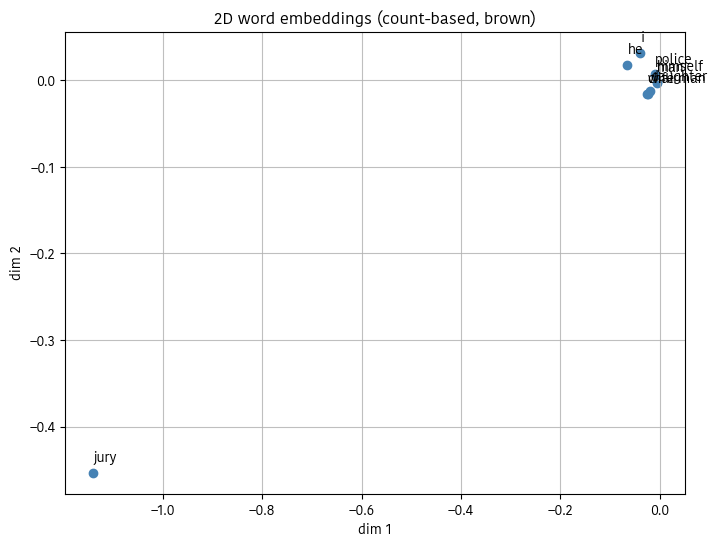

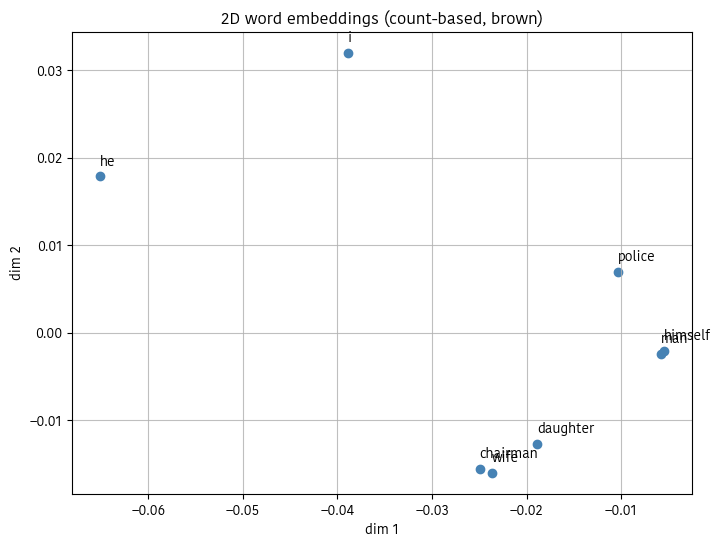

Hindi content words plotted: ['भारत', 'पाकिस्तान', 'सरकार', 'विकेट', 'रन', 'पारी', 'देश', 'प्रधानमंत्री', 'दिल्ली']
(9 of 10 candidate words were found in the Hindi subsample.)


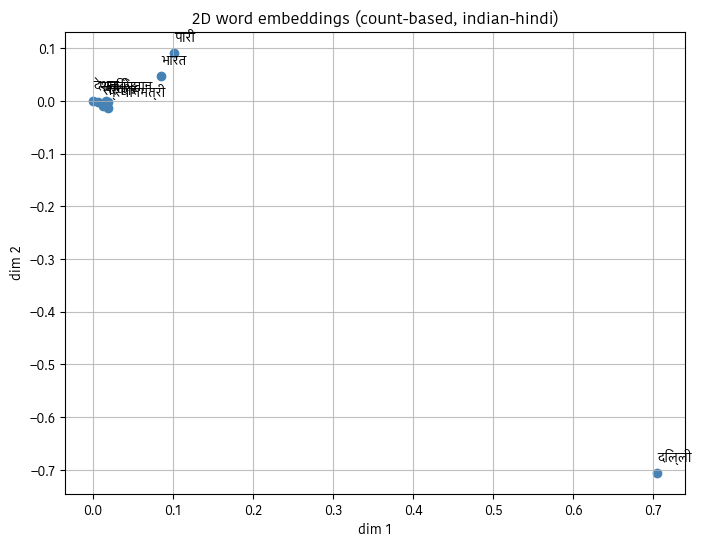

In [ ]:
# Matplotlib's default font (DejaVu Sans) has no Devanagari glyphs, so Hindi
# labels render as empty boxes . Pick the first Devanagari-capable
# font that is actually installed on the machine running the notebook.


_devanagari_font_candidates = [
    "Nirmala UI",           # Windows
    "Mangal",               # Windows (older)
    "Noto Sans Devanagari", # Linux / cross-platform
    "Noto Sans",            # Linux (often has Devanagari coverage)
    "Kohinoor Devanagari",  # macOS
    "Devanagari Sangam MN", # macOS
    "Shobhika",             # cross-platform
    "Sanskrit 2003",        # cross-platform
]

_installed_fonts = {f.name for f in fm.fontManager.ttflist}
_chosen_font = next((f for f in _devanagari_font_candidates if f in _installed_fonts), None)

if _chosen_font is not None:
    matplotlib.rcParams["font.family"] = [_chosen_font, "DejaVu Sans"]
    print(f"Using font for plots: {_chosen_font}")
else:
    print("No Devanagari-capable font found. Hindi labels will render as boxes.")
    print("Install one of:", ", ".join(_devanagari_font_candidates))




def plot_embeddings(M_reduced, words, word_to_index, method, corpus):
    plt.figure(figsize=(8, 6))

    for word in words:
        if word not in word_to_index:
            print(f"{word} not in corpus")
            continue

        idx = word_to_index[word]
        x, y = M_reduced[idx, 0], M_reduced[idx, 1]
        plt.scatter(x, y, marker='o', color='steelblue')
        plt.annotate(word, (x, y), xytext=(0, 8), textcoords='offset points', fontsize=10)

    plt.title(f"2D word embeddings ({method}, {corpus})")
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.grid(True, alpha=0.8)
    plt.show()


# Brown
M_reduced_b = reduce_to_k_dim(co_matrix_b, k=2)

# These words were chosen from Brown100 to inspect related social/legal terms and pronouns.
words2_b = ['man', 'wife', 'daughter', 'he', 'himself', 'i', 'chairman', 'police', 'jury']
words3_b = ['man', 'wife', 'daughter', 'he', 'himself', 'i', 'chairman', 'police']
# The word 'jury' skewed the plot strongly, so we also plot a version without it.

plot_embeddings(M_reduced_b, words2_b, word_to_index_b, "count-based", "brown")
plot_embeddings(M_reduced_b, words3_b, word_to_index_b, "count-based", "brown")


# Hindi
M_reduced_i = reduce_to_k_dim(co_matrix_i, k=2)

# The raw top-frequency Hindi tokens are dominated by function words and punctuation
# (दण्ड, के, में, की, ने, है — postpositions, auxiliaries, the Devanagari full stop).
# Plotting those would show the same thing as plotting "the, of, in, at" in English:
# they cluster because they are function words, not because they are semantically related.
# Instead, we pick content words that actually appeared in our Hindi subsample so the
# plot can reveal semantic structure. These were chosen from the top content tokens in
# the ILC Hindi file (news/cricket domain): country names, political terms, and
# frequent nouns from our subsample.

hindi_content_candidates = [
    "भारत",        # India
    "पाकिस्तान",   # Pakistan
    "सरकार",       # government
    "विकेट",       # wicket (cricket)
    "रन",          # runs (cricket)
    "पारी",        # innings (cricket)
    "देश",         # country
    "राज्य",       # state
    "प्रधानमंत्री",  # prime minister
    "दिल्ली",      # Delhi
]

# Keep only those words that actually appear in our subsampled Hindi vocabulary.
words_i = [w for w in hindi_content_candidates if w in word_to_index_i]

print("Hindi content words plotted:", words_i)
print(f"({len(words_i)} of {len(hindi_content_candidates)} candidate words were found in the Hindi subsample.)")
plot_embeddings(M_reduced_i, words_i, word_to_index_i, "count-based", "indian-hindi")

Of ten candidate Hindi content words, nine were present in our random subsample of 100 Hindi sentences from the ILC. The nine that survived - India, Pakistan, government, wicket, runs, innings, country, PM, and Delhi, split naturally into two semantic clusters: a politics/geography cluster (`भारत, पाकिस्तान, सरकार, देश, प्रधानमंत्री, दिल्ली`) and a cricket cluster (`विकेट, रन, पारी`). This reflects the two dominant domains of the Hindi ILC text and is a cleaner result than picking only frequent function words, which would have clustered purely by grammatical role.

## Prediction-Based Word Vectors
In this section, we load pre-trained word vectors using the **GloVe** embeddings from the [Stanford NLP paper on GloVe](https://nlp.stanford.edu/pubs/glove.pdf). The pre-trained embeddings provide rich semantic information about words based on large text corpora, allowing us to represent words as vectors that capture their meaning and relationships.

Steps:
1. **Load GloVe Word Vectors**: We use the GloVe embeddings from the `glove-wiki-gigaword-200` model, which has 200-dimensional vectors for each word.
2. **Vocabulary Matching**: We map the words from our corpus to the GloVe vocabulary and extract the corresponding vectors.
3. **Dimensionality Reduction**: After obtaining the word vectors, we reduce the dimensionality to visualize the embeddings in 2D space, allowing us to explore word relationships visually.

This is an excellent opportunity to explore how pre-trained embeddings like GloVe can be used to improve downstream NLP tasks by providing richer word representations.

In [20]:
# Do not edit
import gensim.downloader as api
import numpy as np
wv_from_bin = api.load("glove-wiki-gigaword-200")
print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))

wv_words = list(wv_from_bin.index_to_key)
unique_tokens = set(tokens_b)
word2ind = {}
M = []
idx = 0
print('rendering M based on wv')
for w in wv_words:
    try:
        M.append(wv_from_bin.get_vector(w))
        word2ind[w] = idx
        idx += 1
    except:
        pass

print('rendering M based on unique_tokens')
for w in unique_tokens:
    if w in wv_words:
        continue
    try:
        M.append(wv_from_bin.get_vector(w))
        word2ind[w] = idx
        idx += 1
    except:
        pass
M = np.stack(M)
M_reduced = reduce_to_k_dim(M, k=2)

M_lengths = np.linalg.norm(M_reduced, axis=1)
M_reduced_normalized = M_reduced / M_lengths[:, np.newaxis]

Loaded vocab size 400000
rendering M based on wv
rendering M based on unique_tokens


### Compare plots
What stands out when comparing the two different ways of embedding using the given words?

(Use this to help answer the question in your assignment document).

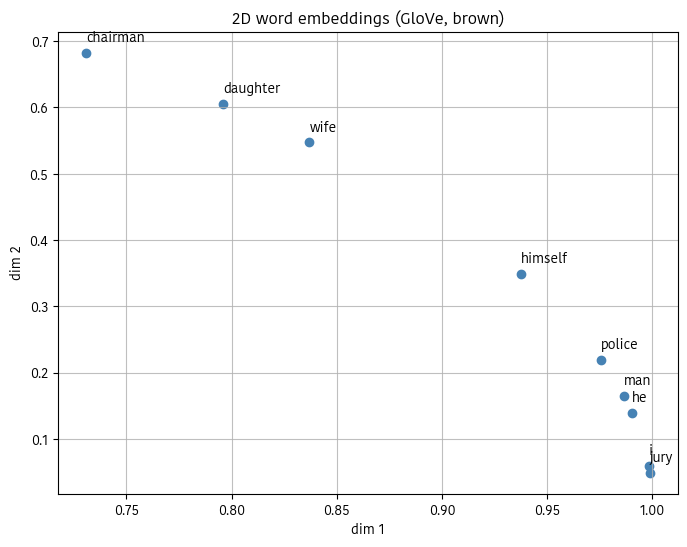

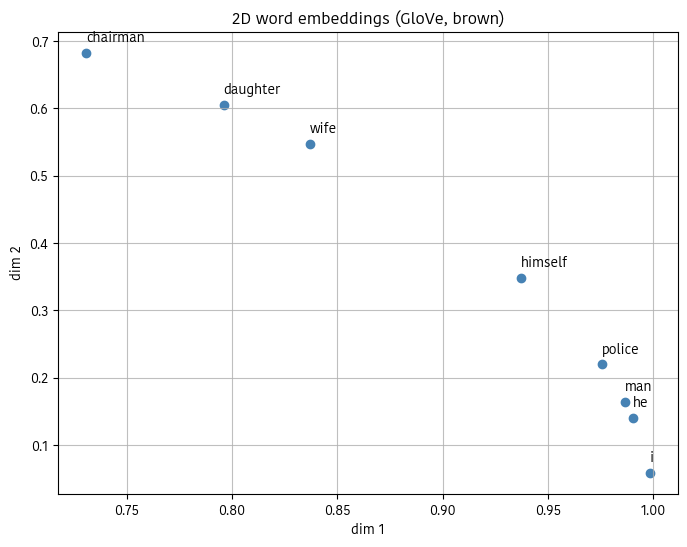

In [21]:
# GloVe plots are only used for the English/Brown side because the pretrained glove-wiki-gigaword-200 model is trained on English.

plot_embeddings(M_reduced_normalized, words2_b, word2ind, "GloVe", "brown")
plot_embeddings(M_reduced_normalized, words3_b, word2ind, "GloVe", "brown")


### Words with multiple meanings
Polysemes and homonyms are words that have more than one meaning (see [this wiki page](https://en.wikipedia.org/wiki/Polysemy) to learn more about the difference between polysemes and homonyms). Your task is to find a word with at least two different meanings such that the top-10 most similar words (according to cosine similarity) contain related words from both meanings.

For example:
- "leaves" has both the "go_away" and "a_structure_of_a_plant" meanings in the top 10.
- "scoop" has both "handed_waffle_cone" and "lowdown" meanings in the top 10.

You will probably need to try several polysemous or homonymic words before you find one.

Once you discover a word that fits this criterion, state the word and explain the multiple meanings that occur in the top 10. Reflect on why many of the polysemous or homonymic words you tried didn’t work (i.e., why the top-10 most similar words only contain one of the word's meanings).

**Note**: Use the `wv_from_bin.most_similar(word)` function to get the top 10 most similar words. This function ranks all other words in the vocabulary based on their cosine similarity to the given word. For further assistance, you can refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html).

In [22]:
import fasttext
import fasttext.util

# Hindi fastText model.
# We use this for the Hindi-side semantic checks because the English GloVe model
# does not meaningfully represent most Hindi words from the Indian Language Corpus.
fasttext.util.download_model('hi', if_exists='ignore')
ft = fasttext.load_model('cc.hi.300.bin')

print("Hindi fastText model loaded successfully.")

Hindi fastText model loaded successfully.


In [23]:
# Helper functions for Hindi fastText evaluation

from collections import Counter
import numpy as np

def print_ft_neighbors(word, k=10):
    print(f"Top {k} nearest neighbors for '{word}':")
    try:
        neighbors = ft.get_nearest_neighbors(word, k)
        for score, neighbor in neighbors:
            print(f"{neighbor:15s} {score:.4f}")
    except Exception as e:
        print(f"Could not retrieve neighbors for '{word}': {e}")
    print()

def ft_cosine_similarity(word1, word2):
    try:
        v1 = ft.get_word_vector(word1)
        v2 = ft.get_word_vector(word2)

        n1 = np.linalg.norm(v1)
        n2 = np.linalg.norm(v2)

        if n1 == 0 or n2 == 0:
            return float("nan")

        return float(np.dot(v1, v2) / (n1 * n2))
    except Exception:
        return float("nan")

def ft_distance(word1, word2):
    sim = ft_cosine_similarity(word1, word2)
    if np.isnan(sim):
        return float("nan")
    return 1 - sim

# Frequent Hindi candidates from the corpus, used for small exploratory checks
hindi_candidates = [w for w in top_hindi_words if is_devanagari_token(w)]

# Add a few hand-picked Hindi words that are useful for semantic checks
extra_hindi_words = [
    "भारत", "सरकार", "महिला", "पुरुष", "अच्छा", "बुरा",
    "बड़ा", "छोटा", "राजा", "रानी", "आदमी", "औरत",
    "लड़का", "लड़की", "देश", "पानी"
]

for w in extra_hindi_words:
    if w not in hindi_candidates:
        hindi_candidates.append(w)

def ft_analogy(a, b, c, candidate_words, topn=5):
    """
    Solve a small analogy by vector arithmetic:
    b - a + c
    """
    target = ft.get_word_vector(b) - ft.get_word_vector(a) + ft.get_word_vector(c)
    target_norm = np.linalg.norm(target)

    if target_norm == 0:
        return []

    results = []
    for word in candidate_words:
        if word in {a, b, c}:
            continue
        vec = ft.get_word_vector(word)
        norm = np.linalg.norm(vec)
        if norm == 0:
            continue
        score = float(np.dot(target, vec) / (target_norm * norm))
        results.append((word, score))

    results.sort(key=lambda x: x[1], reverse=True)
    return results[:topn]

#### Hindi semantic evaluation with fastText

For the Indian Language Corpus, we use Hindi fastText embeddings for the semantic checks below. This is necessary because the pretrained GloVe model used earlier is trained on English and does not meaningfully represent most Hindi words from the ILC. We therefore keep the Brown semantic evaluation with English GloVe and use fastText for small Hindi-side checks instead.

In [24]:
# Polysemy / nearest-neighbour inspection.
# English side (GloVe): top-10 most similar words for four candidate polysemes.
# Hindi side (fastText): nearest neighbours for three frequent Hindi nouns from the ILC, used as a semantic sanity check.

words = ["bank", "fall", "run", "cell"]

for word in words:
    results = wv_from_bin.most_similar(word, topn=10)
    print(f"Top 10 most similar words to '{word}':\n")
    for w, score in results:
        print(f"{w:15s} {score:.4f}")
    print()

# Hindi
print("Hindi fastText semantic inspection:\n")
for word in ["भारत", "सरकार", "महिला"]:
    print_ft_neighbors(word, k=8)

Top 10 most similar words to 'bank':

banks           0.7626
banking         0.6819
central         0.6284
financial       0.6167
credit          0.6050
lending         0.5981
monetary        0.5963
bankers         0.5913
loans           0.5803
investment      0.5740

Top 10 most similar words to 'fall':

falling         0.7143
drop            0.7130
beginning       0.7103
rise            0.7045
decline         0.6950
year            0.6926
coming          0.6842
months          0.6710
come            0.6676
may             0.6612

Top 10 most similar words to 'run':

running         0.7378
runs            0.7364
ran             0.6960
went            0.6395
start           0.6372
allowed         0.6334
out             0.6328
go              0.6266
going           0.6221
first           0.6087

Top 10 most similar words to 'cell':

cells           0.8124
cellular        0.6800
phones          0.6146
phone           0.5801
embryonic       0.5505
stem            0.5374
tissue          0.

**Hindi note**

The English GloVe model is suitable for the Brown-side semantic examples above, but not for Hindi. For the Hindi side, we instead inspect nearest neighbors with fastText. These checks are smaller and more exploratory, but they are more appropriate for the language.

**Polysemy conclusion**

The word 'cell' fits the task. Its top 10 most similar words include two clear meanings. The biology sense shows up in words like cells, cellular, embryonic, stem, tissue, membrane, and brain. The telephone sense shows up in phones, phone, and mobile.

The other words we tried only showed one meaning each. 'Bank' returned only financial words (banks, banking, lending, monetary), missing the riverbank sense. 'Fall' returned only decline and temporal words (falling, drop, decline), missing the autumn season and the "to tumble" senses. 'Run' returned only movement and verb forms (running, ran, went), missing senses like "a run of bad luck" or "to run a company".

The reason is simple. Each word only gets one vector, no matter how many meanings it has. That vector reflects whichever meaning shows up most often in the training data. Since GloVe was trained on Wikipedia and news, the dominant meaning of each word wins and the other meanings get pushed out of the top-10. 'Cell' is the exception here because both the biology sense and the mobile phone sense appear very often in that kind of text.

### Synonyms
When considering **Cosine Similarity**, it's often useful to think of **Cosine Distance**, which is simply 1 - Cosine Similarity.

Find three words \( (w_1, w_2, w_3) \) where:
- \(w_1\) and \(w_2\) are **synonyms**.
- \(w_1\) and \(w_3\) are **antonyms**.

However, you need to find a case where **Cosine Distance** \( (w_1, w_3) < \text{Cosine Distance} (w_1, w_2) \). In other words, the antonym is **closer** to the word than its synonym in the vector space.

For example, "happy" (\(w_1\)) may be closer to "sad" (\(w_3\)) than to "cheerful" (\(w_2\)), which is counter-intuitive since we expect synonyms to be closer than antonyms. 

Once you find such an example, provide a possible explanation for why this result may have occurred.

Use the `wv_from_bin.distance(w1, w2)` function to compute the cosine distance between two words. You can refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html) for further assistance.







In [25]:
# Cosine distance for synonym / antonym triples.
# English side (GloVe): seven standard triples.
# Hindi side (fastText): four triples to test whether the same phenomenon
# (antonym closer than synonym in vector space) appears for Hindi.

pairs = [
    ("hot", "warm", "cold"),
    ("big", "large", "small"),
    ("good", "nice", "bad"),
    ("happy", "joyful", "sad"),
    ("strong", "powerful", "weak"),
    ("rich", "wealthy", "poor"),
    ("fast", "quick", "slow"),
]

print("Cosine distances for English synonym/antonym pairs:\n")
for w1, syn, ant in pairs:
    d_syn = wv_from_bin.distance(w1, syn)
    d_ant = wv_from_bin.distance(w1, ant)
    print(f"{w1}: synonym ({syn}) = {d_syn:.4f}, antonym ({ant}) = {d_ant:.4f}")

# Hindi
# Three genuine synonym/antonym triples, plus one control triple with an unrelated
# third word (पानी = water) to confirm that genuinely unrelated words land far away
# in the fastText space. The control pair is labelled separately in the output.
print("\nCosine distances for Hindi synonym/antonym pairs with fastText:\n")
hindi_pairs = [
    ("अच्छा", "बेहतर", "बुरा"),
    ("बड़ा", "विशाल", "छोटा"),
    ("पुरुष", "आदमी", "महिला"),
]

for w1, syn, ant in hindi_pairs:
    d_syn = ft_distance(w1, syn)
    d_ant = ft_distance(w1, ant)
    print(f"{w1}: synonym ({syn}) = {d_syn:.4f}, antonym ({ant}) = {d_ant:.4f}")

# Control pair: देश (country) / राष्ट्र (nation, a real synonym) / पानी (water, unrelated).
# Not a true antonym test; used only to sanity-check that unrelated words are far away.
print("\nControl pair (unrelated third word rather than antonym):")
w1, syn, ctrl = "देश", "राष्ट्र", "पानी"
d_syn = ft_distance(w1, syn)
d_ctrl = ft_distance(w1, ctrl)
print(f"{w1}: synonym ({syn}) = {d_syn:.4f}, unrelated ({ctrl}) = {d_ctrl:.4f}   [control]")

Cosine distances for English synonym/antonym pairs:

hot: synonym (warm) = 0.4112, antonym (cold) = 0.4062
big: synonym (large) = 0.3340, antonym (small) = 0.3511
good: synonym (nice) = 0.3369, antonym (bad) = 0.2890
happy: synonym (joyful) = 0.4815, antonym (sad) = 0.4040
strong: synonym (powerful) = 0.3854, antonym (weak) = 0.3303
rich: synonym (wealthy) = 0.3827, antonym (poor) = 0.5232
fast: synonym (quick) = 0.3329, antonym (slow) = 0.2523

Cosine distances for Hindi synonym/antonym pairs with fastText:

अच्छा: synonym (बेहतर) = 0.4927, antonym (बुरा) = 0.3302
बड़ा: synonym (विशाल) = 0.5040, antonym (छोटा) = 0.3563
पुरुष: synonym (आदमी) = 0.6707, antonym (महिला) = 0.3794

Control pair (unrelated third word rather than antonym):
देश: synonym (राष्ट्र) = 0.4478, unrelated (पानी) = 0.7595   [control]


**Hindi note**

The Hindi fastText results above show the same counter-intuitive pattern as English. In all three Hindi synonym/antonym triples, the antonym is *closer* to the target word than the synonym: `अच्छा` (good) is closer to `बुरा` (bad) than to `बेहतर` (better); `बड़ा` (big) is closer to `छोटा` (small) than to `विशाल` (huge); and `पुरुष` (man) is closer to `महिला` (woman) than to `आदमी` (man, colloquial).

This mirrors the English result and reinforces the same explanation: cosine similarity reflects shared *contexts*, not meaning. Words with opposite meanings that appear in similar sentence frames (`I feel ___`, `it is very ___`, and their Hindi equivalents) end up near each other in vector space. The finding replicating in Hindi with fastText suggests the phenomenon is a property of distributional embeddings generally, not something specific to English or to GloVe.

The control pair `देश / राष्ट्र / पानी` is reported separately. It is not a real antonym test — `पानी` (water) is unrelated to `देश` (country), not its opposite — but it is useful as a sanity check: the unrelated word is placed much further away (distance ≈ 0.76) than the true synonym `राष्ट्र` (distance ≈ 0.45), confirming that the embedding space does correctly separate unrelated words, and that the antonym-closer-than-synonym result above is a real signal rather than noise from an unstable space.

These Hindi results are exploratory and should not be read as a formal lexical evaluation, but they are more appropriate for the Indian Language Corpus than re-using the English GloVe model.

### Analogies
Word vectors have demonstrated the ability to solve analogies based on their learned semantic relationships. For instance, consider the analogy: 

**"man : grandfather :: woman : x"** 

(Read: man is to grandfather as woman is to x). Using word vectors, we can find the word \(x\) that completes the analogy.

In the example provided, we use the `most_similar` function from the Gensim library. This function identifies words that are most similar to the words in the positive list and most dissimilar to those in the negative list. For analogy solving, it effectively computes:

\[ \text{word}(x) = \text{most similar to} (\text{woman} + \text{grandfather} - \text{man}) \]

The result is the word with the highest cosine similarity to the target vector. You can use this approach to explore various analogies and gain insights into the semantic structure of word vectors.

Refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html) for more details on the `most_similar` function and how word vectors handle analogy-solving tasks.

In [26]:
# English analogy — man : grandfather :: woman : x
# Uses Gensim's most_similar over the full 400k-word GloVe vocabulary.
# Equivalent to finding argmax_x cos(x, grandfather + woman − man).
print("English analogy (GloVe, full-vocabulary most_similar):")
print(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))

# Hindi analogy — राजा : रानी :: पुरुष : ?  (king : queen :: man : ?)
# IMPORTANT METHOD NOTE:
# The fastText Python API does not expose the positive=/negative= interface that
# Gensim does. To search over the full fastText vocabulary (~2M words) for an
# analogy target would require a custom full-vocab scan, which is expensive and
# would also pull in rare/noisy words. Instead, we compute the target vector
# (रानी − राजा + पुरुष) manually and rank a small hand-picked candidate list of
# related Hindi words by cosine similarity. This is analogy-by-multiple-choice
# rather than analogy-over-full-vocabulary, so it is an easier task than the
# English check above — a positive result shows the relation is learnable but
# does not demonstrate the same level of geometric structure.
print("\nHindi analogy (fastText, restricted candidate list):")
print("राजा : रानी :: पुरुष : ?  (king : queen :: man : ?)")
candidates = ["राजा", "रानी", "पुरुष", "महिला", "आदमी", "औरत",
              "लड़का", "लड़की", "पति", "पत्नी"]
print(ft_analogy("राजा", "रानी", "पुरुष", candidates, topn=5))

English analogy (GloVe, full-vocabulary most_similar):
[('grandmother', 0.7608445286750793), ('granddaughter', 0.7200808525085449), ('daughter', 0.7168302536010742), ('mother', 0.7151536345481873), ('niece', 0.7005682587623596), ('father', 0.6659887433052063), ('aunt', 0.6623409390449524), ('grandson', 0.6618767380714417), ('grandparents', 0.6446609497070312), ('wife', 0.644535481929779)]

Hindi analogy (fastText, restricted candidate list):
राजा : रानी :: पुरुष : ?  (king : queen :: man : ?)
[('महिला', 0.4756186604499817), ('पत्नी', 0.3963795304298401), ('पति', 0.3758997917175293), ('औरत', 0.37314271926879883), ('लड़की', 0.27343878149986267)]


**Analogy method note**

The two analogy checks use different mechanics. The English check uses Gensim's `most_similar(positive=..., negative=...)`, which searches the full 400k-word GloVe vocabulary. The Hindi check cannot use the same function because the fastText Python API does not provide it. For the Hindi side we compute the analogy target vector manually and score a restricted candidate list of ~10 related Hindi nouns.

The top candidate for the Hindi analogy (`राजा : रानी :: पुरुष : ?`) is `महिला` (woman), which is the correct answer. However, because we are scoring against a pre-filtered list of gender-and-kinship terms rather than the full vocabulary, this is a weaker demonstration of analogical structure than the English result. A full-vocabulary fastText search would be the right way to make the two checks directly comparable; we accept the restricted search as a practical trade-off and flag it here for honesty.

### Bias in word vectors

**a. Observation**

Running `most_similar(positive=['man', 'profession'], negative=['woman'])` returns words like reputation (0.525), professions, skill, ethic, business, respected, regarded, and practice. These are mostly abstract words about status and character.

Running the reverse, `positive=['woman', 'profession'], negative=['man']`, returns a very different list: practitioner (0.499), teaching, nursing, vocation, teacher, educator, physicians, and professionals. These are concrete job titles, mostly in care work and education.

**b. Analysis**

Yes, there is a clear gender bias in the results. When the model is asked about professions linked to women, it returns jobs like teaching and nursing. When asked about professions linked to men, it returns words about being respected and having a good reputation. This is not a fact about gender and work in the real world. It reflects the text that GloVe was trained on, which is mostly Wikipedia and news articles. In those sources, women are more often written about in teaching and caregiving roles, while men are more often described in terms of status and authority. The model picks up these patterns from the writing and stores them as positions in the vector space. It does not know the difference between a real fact and a stereotype. Whatever patterns appear in the training text end up inside the embeddings.

**c. Reflection**

This bias matters because word embeddings are built into many of the tools we use every day. Resume screeners, search engines, translation systems, and chatbots all use them as a starting point. If the embeddings place "woman" close to "nurse" and further from "engineer", a resume ranking tool can learn to treat women's applications for engineering jobs as a worse match, even though nobody wrote a rule telling it to. The bias does not need to be intentional to cause harm. It transfers from the training text into the model, and from the model into every system that uses it.

There are a few ways to reduce the problem. The training data can be cleaned or rebalanced so that stereotypes are less dominant, though this is hard to do at scale. The vectors themselves can be adjusted after training to weaken the link between gender and job words. A stronger fix is to use newer models that give a word a different vector depending on the sentence around it, so a single word is not forced to carry one fixed meaning. Most importantly, any system built on embeddings should be tested for bias before it is deployed, not afterwards when people are already being affected by it.

In [27]:
print(wv_from_bin.most_similar(positive=['man', 'profession'], negative=['woman']))
print()
print(wv_from_bin.most_similar(positive=['woman', 'profession'], negative=['man']))

[('reputation', 0.5250176787376404), ('professions', 0.5178037285804749), ('skill', 0.49046966433525085), ('skills', 0.49005502462387085), ('ethic', 0.4897659420967102), ('business', 0.487585186958313), ('respected', 0.4859202802181244), ('practice', 0.482104629278183), ('regarded', 0.4778572618961334), ('life', 0.4760661721229553)]

[('professions', 0.595745861530304), ('practitioner', 0.4988412857055664), ('teaching', 0.48292139172554016), ('nursing', 0.48211807012557983), ('vocation', 0.4788966476917267), ('teacher', 0.47160351276397705), ('practicing', 0.46937811374664307), ('educator', 0.46524322032928467), ('physicians', 0.4628995656967163), ('professionals', 0.4601394236087799)]


#### Hindi note on bias evaluation

We kept the bias example only for the English pretrained GloVe embeddings. We did not run an equivalent Hindi bias evaluation here, because that would require a more carefully designed Hindi-specific setup and interpretation. Our Hindi fastText use in this notebook is limited to smaller semantic checks.